In [141]:
from neural_priors.utils.data import Subject, get_all_subject_ids

from tqdm.contrib.itertools import product
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

bids_folder = '/data/ds-neuralpriors'
roi = 'NPCr'

In [142]:
natural_pars_unsmoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.natural_space', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
natural_pars_smoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.natural_space.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
natural_pars = pd.concat([natural_pars_unsmoothed, natural_pars_smoothed], keys=['unsmoothed', 'smoothed'], names=['smoothing'], axis=0)
natural_pars[('non_monotonic', 'narrow')] = (natural_pars[('mu', 'narrow')] > 10.5) & (natural_pars[('mu', 'narrow')] < 25.0)
natural_pars[('non_monotonic', 'wide')] = (natural_pars[('mu', 'wide')] > 10.5) & (natural_pars[('mu', 'wide')] < 40.0)

logspace_pars_unsmoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.logspace', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
logspace_pars_smoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.logspace.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
logspace_pars = pd.concat([logspace_pars_unsmoothed, logspace_pars_smoothed], keys=['unsmoothed', 'smoothed'], names=['smoothing'], axis=0)
logspace_pars[('non_monotonic', 'narrow')] = (logspace_pars[('mu', 'narrow')] > np.log(10.5)) & (logspace_pars[('mu', 'narrow')] < np.log(25.0))
logspace_pars[('non_monotonic', 'wide')] = (logspace_pars[('mu', 'wide')] > np.log(10.5)) & (logspace_pars[('mu', 'wide')] < np.log(40.0))

# pars = pd.concat([natural_pars_unsmoothed, natural_pars_smoothed, logspace_pars_unsmoothed, logspace_pars_smoothed],
#                  keys=[('natural', 'unsmoothed'), ('natural', 'smoothed'), ('logspace', 'unsmoothed'), ('logspace', 'smoothed')],
#                     names=['space', 'smoothing'], axis=0)

pars = pd.concat([natural_pars, logspace_pars], keys=['natural', 'logspace'], names=['space'], axis=0)

pars.rename_axis(index={'level_3':'voxel', None:'voxel', 'subject_id':'subject'}, inplace=True)

cvr2 = pars['cvr2']
cvr2.columns = ['cvr2']
cvr2 = cvr2.unstack(['space', 'model_label'])#['cvr2'].drop([ 5, 6, 7, 8], axis=1)

mask = cvr2.gt(0).any(axis=1) & cvr2.notna().all(axis=1)

masked_cvr2 = cvr2[mask]

In [143]:
# pars= pars[pars[('cvr2', 'nan')].gt(0)]

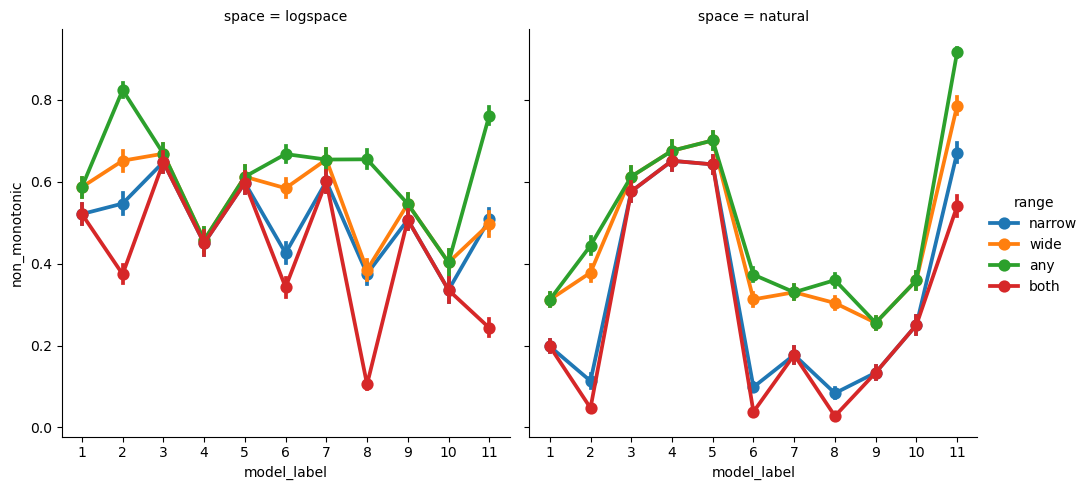

In [144]:
# non_monotonic = pars.groupby(['subject', 'space', 'smoothing', 'model_label'])['non_monotonic'].mean()['non_monotonic']
non_monotonic = pars.xs('smoothed', level='smoothing')['non_monotonic']
non_monotonic['any'], non_monotonic['both'] = non_monotonic.any(axis=1), non_monotonic.all(axis=1)

non_monotonic = non_monotonic.groupby(['subject', 'space', 'model_label']).mean().stack().to_frame('non_monotonic')

sns.catplot(x='model_label', y='non_monotonic', hue='range', col='space', data=non_monotonic.reset_index(), kind='point', errorbar='se')

# non_monotonic

In [145]:
pars.loc['natural', 'nonmonotonic'] = (
    ((pars.loc['natural', ('mu', 'narrow')] > 10) &
     (pars.loc['natural', ('mu', 'wide')] > 10) &
     (pars.loc['natural', ('mu', 'narrow')] < 25) &
     (pars.loc['natural', ('mu', 'wide')] < 40))
    .all()
)

pars.loc['logspace', 'nonmonotonic'] = (
    ((pars.loc['logspace', ('mu', 'narrow')] > np.log(10)) &
     (pars.loc['logspace', ('mu', 'wide')] > np.log(10)) &
     (pars.loc['logspace', ('mu', 'narrow')] < np.log(25)) &
     (pars.loc['logspace', ('mu', 'wide')] < np.log(40)))
    .all()
)


In [146]:
pars.groupby(['subject', 'space', 'smoothing', 'model_label'])['nonmonotonic'].mean()

subject  space     smoothing   model_label
1        logspace  smoothed    1              0.0
                               2              0.0
                               3              0.0
                               4              0.0
                               5              0.0
                                             ... 
41       natural   smoothed    8              0.0
                               9              0.0
                               10             0.0
                               11             0.0
                   unsmoothed  9              0.0
Name: nonmonotonic, Length: 979, dtype: object

(10.0, 40.0)

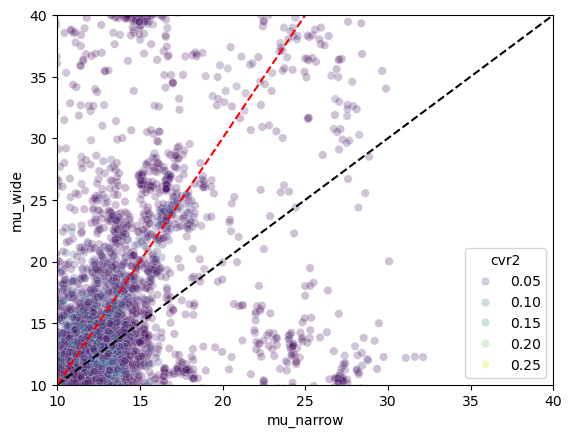

In [147]:
pars11 = pars.loc[('natural', 'smoothed')].xs(11, level='model_label')
pars11.columns = [f'{x[0]}_{x[1]}' if x[0] not in ['r2', 'cvr2'] else x[0] for x in pars11.columns]

pars11 = pars11.loc[pars11.cvr2 > 0.0]

sns.scatterplot(x='mu_narrow', y='mu_wide', hue='cvr2', data=pars11, palette='viridis', alpha=0.25)
plt.plot([10, 40], [10, 40], 'k--')

slope = 2.
intercept = 10.
plt.plot([10, 40], [10, 10+slope*(40-10)], 'r--')

plt.xlim(10, 40)
plt.ylim(10, 40)

(10.0, 40.0)

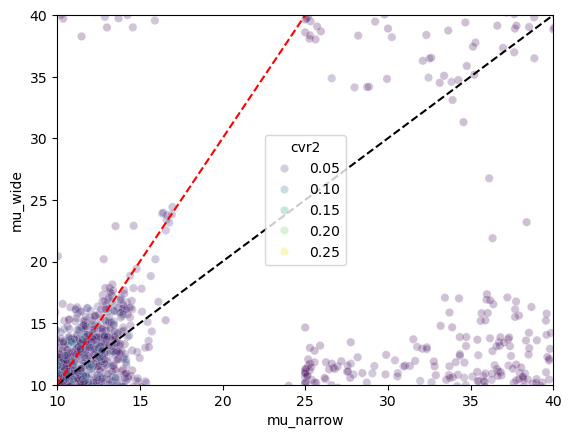

In [148]:
pars8 = pars.loc[('natural', 'smoothed')].xs(8, level='model_label')
pars8.columns = [f'{x[0]}_{x[1]}' if x[0] not in ['r2', 'cvr2'] else x[0] for x in pars8.columns]

pars8 = pars8.loc[pars8.cvr2 > 0.0]

sns.scatterplot(x='mu_narrow', y='mu_wide', hue='cvr2', data=pars8, palette='viridis', alpha=0.25)
plt.plot([10, 40], [10, 40], 'k--')

slope = 2.
intercept = 10.
plt.plot([10, 40], [10, 10+slope*(40-10)], 'r--')

plt.xlim(10, 40)
plt.ylim(10, 40)

(1.0, 3.0)

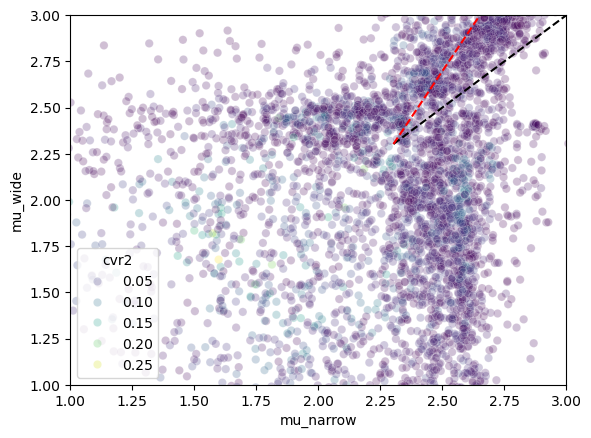

In [149]:
pars11 = pars.loc[('logspace', 'smoothed')].xs(11, level='model_label')
pars11.columns = [f'{x[0]}_{x[1]}' if x[0] not in ['r2', 'cvr2'] else x[0] for x in pars11.columns]

pars11 = pars11.loc[pars11.cvr2 > 0.0]

sns.scatterplot(x='mu_narrow', y='mu_wide', hue='cvr2', data=pars11, palette='viridis', alpha=0.25)

plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(40)], 'k--')
slope = 2.
plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10)+slope*(np.log(40)-np.log(10))], 'r--')

plt.xlim(1., 3.)
plt.ylim(1. ,3.)

(1.0, 3.5)

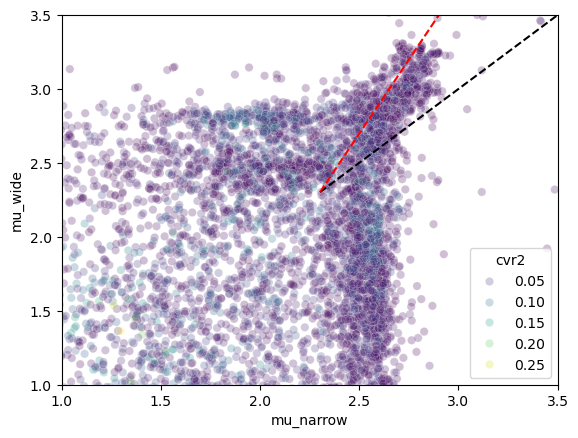

In [150]:
pars8 = pars.loc[('logspace', 'smoothed')].xs(8, level='model_label')
pars8.columns = [f'{x[0]}_{x[1]}' if x[0] not in ['r2', 'cvr2'] else x[0] for x in pars8.columns]

pars8 = pars8.loc[pars8.cvr2 > 0.0]

sns.scatterplot(x='mu_narrow', y='mu_wide', hue='cvr2', data=pars8, palette='viridis', alpha=0.25)

plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(40)], 'k--')
slope = 2.
plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10)+slope*(np.log(40)-np.log(10))], 'r--')

plt.xlim(1., 3.5)
plt.ylim(1. ,3.5)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18469/4185959379.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['cvr2_diff'] = np.clip(tmp['cvr2.4'] - tmp['cvr2.8'], -0.02, 0.02)


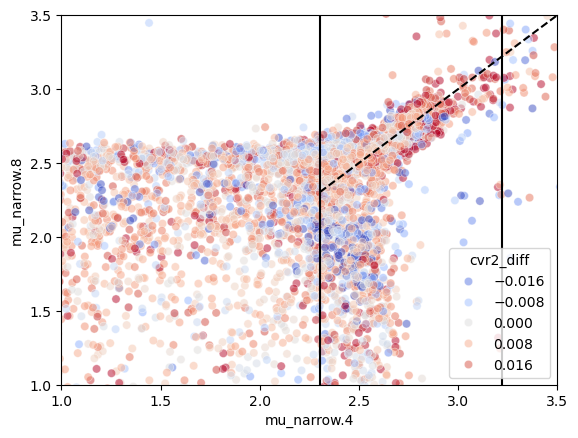

In [190]:
pars4 = pars.loc[('logspace', 'smoothed', slice(None), [4, 8])]

pars4 = pars4.unstack('model_label')

mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

tmp = pars4[['mu', 'cvr2']]

tmp.columns = [f'{x[0]}_{x[1]}.{x[2]}' if x[0] not in ['r2', 'cvr2'] else f'{x[0]}.{x[2]}' for x in tmp.columns]

tmp['cvr2_diff'] = np.clip(tmp['cvr2.4'] - tmp['cvr2.8'], -0.02, 0.02)

sns.scatterplot(x='mu_narrow.4', y='mu_narrow.8', hue='cvr2_diff', data=tmp, palette='coolwarm', alpha=0.5)

plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(40)], 'k--')

plt.xlim(1., 3.5)
plt.ylim(1. ,3.5)

plt.axvline(np.log(10), color='k')
plt.axvline(np.log(25), color='k')



/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18469/554293717.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['cvr2_diff'] = np.clip(tmp['cvr2.4'] - tmp['cvr2.8'], -0.02, 0.02)


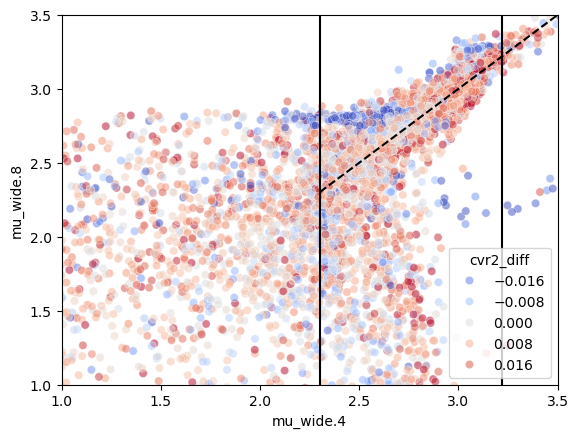

In [ ]:
pars4 = pars.loc[('logspace', 'smoothed', slice(None), [4, 8])]

pars4 = pars4.unstack('model_label')

mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

tmp = pars4[['mu', 'cvr2']]

tmp.columns = [f'{x[0]}_{x[1]}.{x[2]}' if x[0] not in ['r2', 'cvr2'] else f'{x[0]}.{x[2]}' for x in tmp.columns]

tmp['cvr2_diff'] = np.clip(tmp['cvr2.4'] - tmp['cvr2.8'], -0.02, 0.02)

sns.scatterplot(x='mu_wide.4', y='mu_wide.8', hue='cvr2_diff', data=tmp, palette='coolwarm', alpha=0.5)

plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(40)], 'k--')

plt.xlim(1., 3.5)
plt.ylim(1. ,3.5)

plt.axvline(np.log(10), color='k')
plt.axvline(np.log(25), color='k')



/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18469/3009151723.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['cvr2_diff'] = np.clip(tmp['cvr2.4'] - tmp['cvr2.8'], -0.02, 0.02)


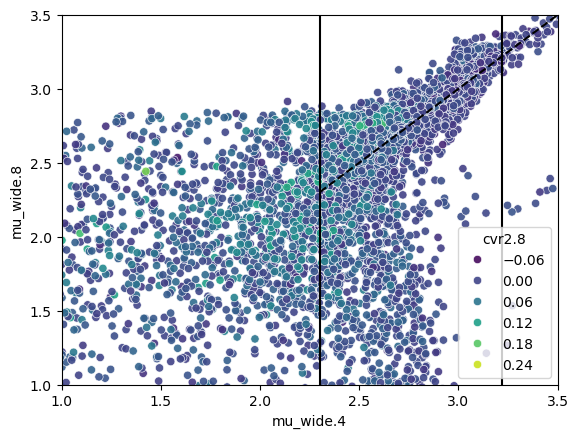

In [195]:
pars4 = pars.loc[('logspace', 'smoothed', slice(None), [4, 8])]

pars4 = pars4.unstack('model_label')

mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

tmp = pars4[['mu', 'cvr2']]

tmp.columns = [f'{x[0]}_{x[1]}.{x[2]}' if x[0] not in ['r2', 'cvr2'] else f'{x[0]}.{x[2]}' for x in tmp.columns]

tmp['cvr2_diff'] = np.clip(tmp['cvr2.4'] - tmp['cvr2.8'], -0.02, 0.02)

sns.scatterplot(x='mu_wide.4', y='mu_wide.8', hue='cvr2.8', data=tmp, palette='viridis', alpha=0.9)

plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(40)], 'k--')

plt.xlim(1., 3.5)
plt.ylim(1. ,3.5)

plt.axvline(np.log(10), color='k')
plt.axvline(np.log(25), color='k')



In [187]:
tmp['cvr2_diff'].describe()

count    10141.000000
mean         0.004092
std          0.011761
min         -0.067652
25%         -0.002179
50%          0.005243
75%          0.011150
max          0.073095
Name: cvr2_diff, dtype: float64

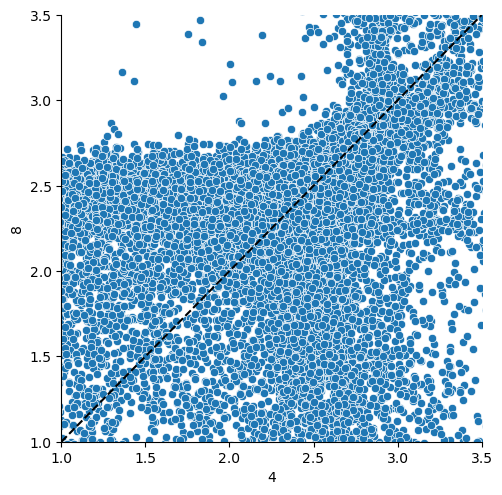

In [166]:
pars4 = pars.loc[('logspace', 'smoothed', slice(None), [4, 8])]

sns.relplot(data=pars4['mu'].unstack('model_label')['narrow'].reset_index(), x=4, y=8, kind='scatter')

plt.xlim(1, 3.5)
plt.ylim(1, 3.5)

plt.plot([1, 3.5], [1, 3.5], 'k--')

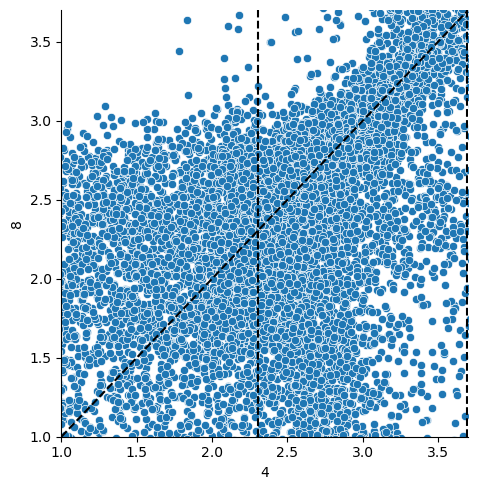

In [167]:
pars4 = pars.loc[('logspace', 'smoothed', slice(None), [4, 8])]

# pars4 = pars4[pars4.cvr2 > 0.0]

sns.relplot(data=pars4['mu'].unstack('model_label')['wide'].reset_index(), x=4, y=8, kind='scatter')

plt.xlim(1, 3.7)
plt.ylim(1, 3.7)

plt.plot([1, 3.7], [1, 3.7], 'k--')
plt.axvline(np.log(10), color='k', linestyle='--')
plt.axvline(np.log(40), color='k', linestyle='--')

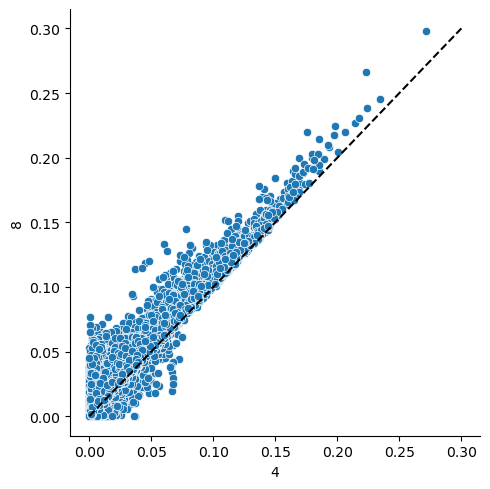

In [168]:
sns.relplot(data=pars4[('r2', 'nan')].unstack('model_label').reset_index(), x=4, y=8, kind='scatter')
plt.plot([0, .3], [0, .3], 'k--')

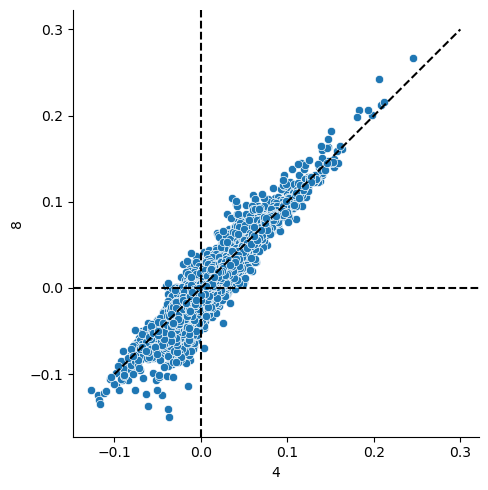

In [170]:
sns.relplot(data=pars4[('cvr2', 'nan')].unstack('model_label').reset_index(), x=4, y=8, kind='scatter')
plt.plot([-.1, .3], [-.1, .3], 'k--')
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')

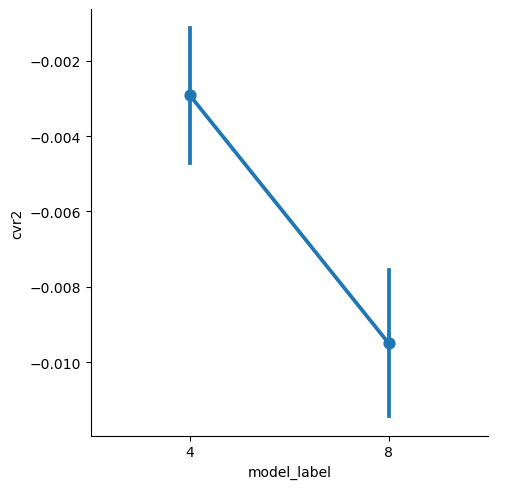

In [164]:
sns.catplot(x='model_label', y='cvr2', data=pars4[('cvr2', 'nan')].groupby(['subject', 'model_label']).mean().to_frame('cvr2').reset_index()
            , kind='point', errorbar='se')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18469/4125042212.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([1, 2])


[]

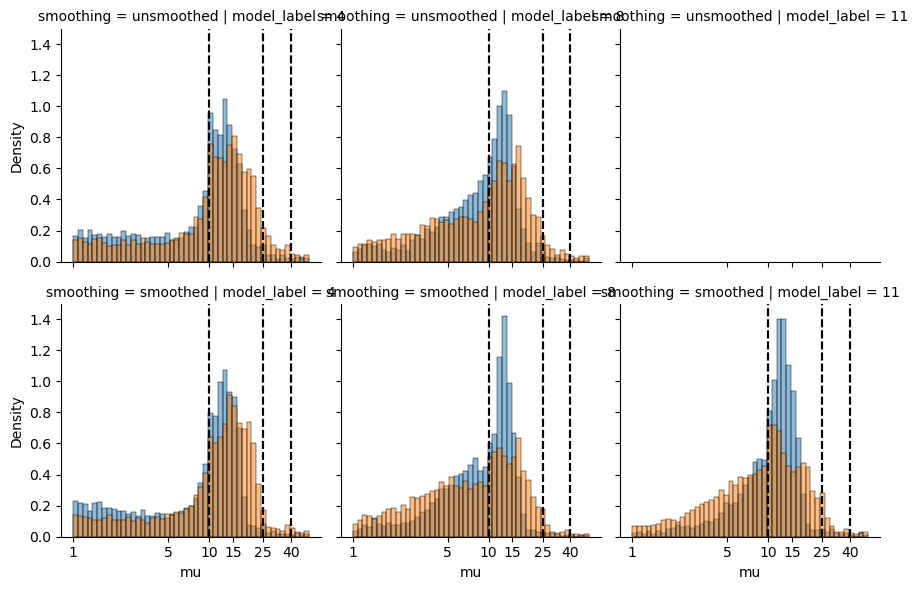

In [ ]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [4, 8, 11])]

pars4 = pars4.unstack('model_label')

mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

mu = pars4[['mu']].stack([1, 2])
g = sns.FacetGrid(mu.reset_index(), col='model_label', hue='range', row='smoothing')

g.map(sns.histplot, 'mu', bins=np.linspace(0, 4, 50), alpha=0.5, stat='densitya')

g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')

# Put natural space xticks
g.axes[0, 0].set_xticks(np.log([1, 5, 10, 15, 25, 40]))
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18469/2109281982.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([0, 2])


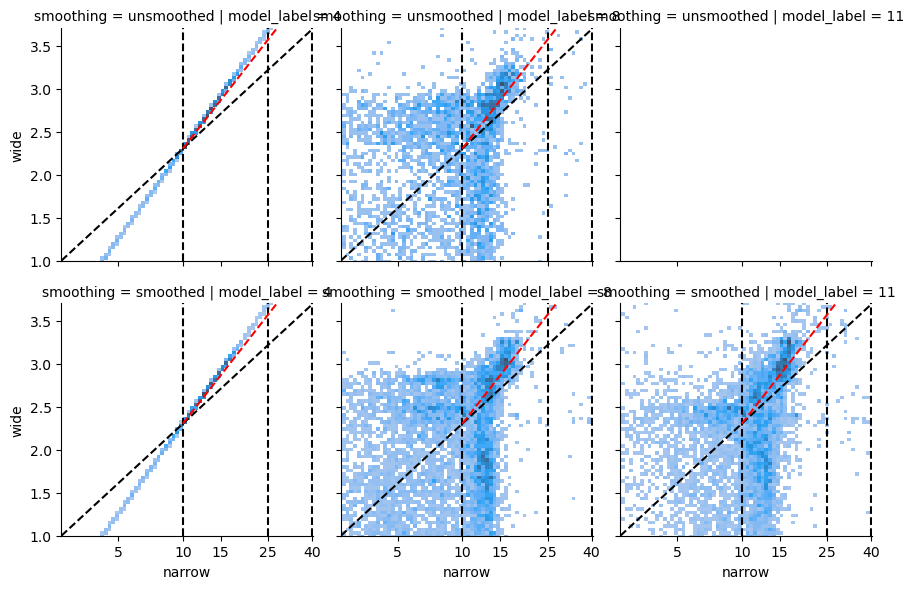

In [275]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [4, 8, 11])]

pars4 = pars4.unstack('model_label')

mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

pars4

mu = pars4[['mu']].stack([0, 2])

mu
g = sns.FacetGrid(mu.reset_index(), col='model_label', row='smoothing')

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 4, 100), np.linspace(0, 4, 100)])

g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks(np.log([1, 5, 10, 15, 25, 40]))
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


g.set(xlim=(1, 3.7), ylim=(1, 3.7))

g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = np.log(40) - np.log(10)
g.map(lambda *args, **kwargs: plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10) + slope*(np.log(40) - np.log(10))], 'r--'))


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18469/3451984604.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = pars4.stack('model_label')


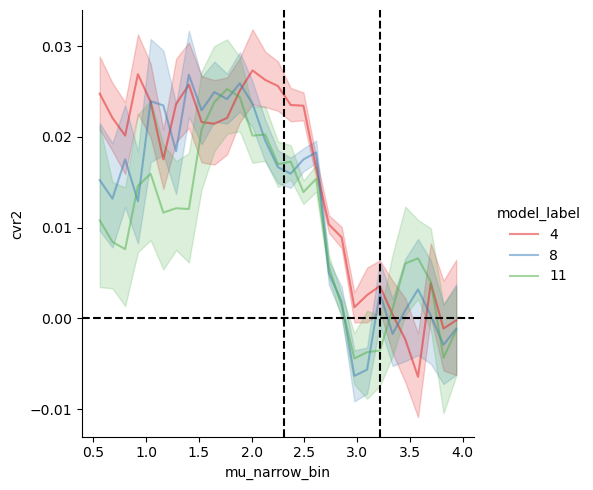

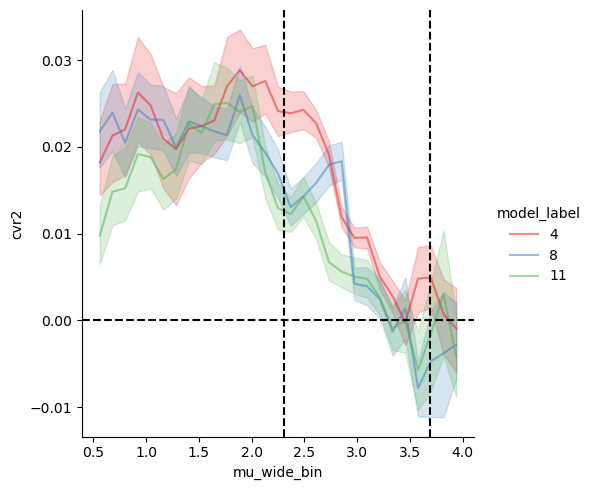

In [240]:
tmp = pars4.stack('model_label')

tmp['mu_narrow_bin'] = pd.cut(tmp['mu', 'narrow'], bins=np.linspace(.5, 4, 30))
tmp['mu_narrow_bin'] = tmp['mu_narrow_bin'].apply(lambda x: x.mid)
tmp['mu_wide_bin'] = pd.cut(tmp['mu', 'wide'], bins=np.linspace(.5, 4, 30))
tmp['mu_wide_bin'] = tmp['mu_wide_bin'].apply(lambda x: x.mid)

tmp = tmp[[('cvr2', 'nan'), ('mu_narrow_bin', ''), ('mu_wide_bin', '')]].droplevel(1, axis=1)

g = sns.relplot(x='mu_narrow_bin', y='cvr2', data=tmp.reset_index(), alpha=0.5, kind='line', hue='model_label', palette='Set1')
g.map(plt.axhline, y=0, color='k', linestyle='--')
g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')


g = sns.relplot(x='mu_wide_bin', y='cvr2', data=tmp.reset_index(), alpha=0.5, kind='line', hue='model_label', palette='Set1')

g.map(plt.axhline, y=0, color='k', linestyle='--')
g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')
